## Flipkart Reviews Sentiment Analysis using Sklearn, NLTK, WorldCloud.

### 1. Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### 2. Loading Dataset

In [2]:
!wget https://media.githubusercontent.com/media/fatahrahimi330/100-Machine-Learning-Projects/refs/heads/master/33-Flipkart%20Reviews%20Sentiment%20%20Analysis/flipkart_data.csv

--2026-03-22 05:10:43--  https://media.githubusercontent.com/media/fatahrahimi330/100-Machine-Learning-Projects/refs/heads/master/33-Flipkart%20Reviews%20Sentiment%20%20Analysis/flipkart_data.csv
Resolving media.githubusercontent.com (media.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to media.githubusercontent.com (media.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1022716 (999K) [text/plain]
Saving to: ‘flipkart_data.csv’

flipkart_data.csv   100%[===================>] 998.75K  --.-KB/s    in 0.1s    

2026-03-22 05:10:43 (7.76 MB/s) - ‘flipkart_data.csv’ saved [1022716/1022716]



In [3]:
df = pd.read_csv('flipkart_data.csv')
df.head()

,review,rating
0,It was nice produt. I like it's design a lot. ...,5
1,awesome sound....very pretty to see this nd th...,5
2,awesome sound quality. pros 7-8 hrs of battery...,4
3,I think it is such a good product not only as ...,5
4,awesome bass sound quality very good bettary l...,5


### 3. Data Prerocessing

1. Exploratory Data Analysis

In [4]:
df.shape

(9976, 2)

In [5]:
df.describe()

,rating
count,9976.000000
mean,4.215417
std,1.167911
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9976 entries, 0 to 9975
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   review  9976 non-null   object
 1   rating  9976 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 156.0+ KB


In [8]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def process_stopwords(df):
    df['review'] = df['review'].str.lower()
    df['review'] = df['review'].apply(lambda x: ' '.join([word for word in x.split() if word not in stop_words]))
    df['sentiment'] = df['rating'].apply(lambda x: 1 if x>= 4 else 0)
    return df

df_cleaned = process_stopwords(df)
df_cleaned.head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,review,rating,sentiment
0,nice produt. like design lot. easy carry. and....,5,1
1,awesome sound....very pretty see nd sound qual...,5,1
2,awesome sound quality. pros 7-8 hrs battery li...,4,1
3,think good product per quality also design qui...,5,1
4,awesome bass sound quality good bettary long l...,5,1


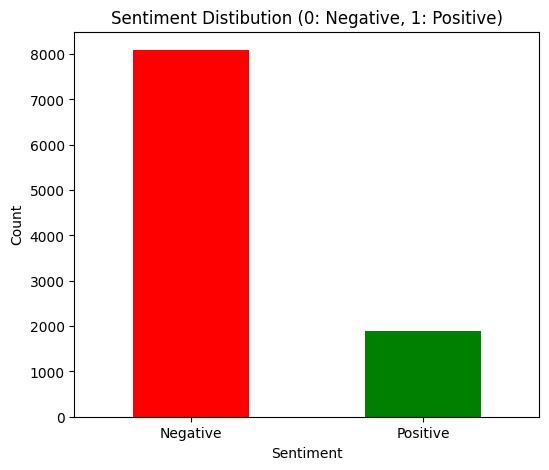

In [10]:
plt.figure(figsize=(6, 5))
df_cleaned['sentiment'].value_counts().plot(kind='bar', color=['red', 'green'])
plt.title('Sentiment Distibution (0: Negative, 1: Positive)')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['Negative', 'Positive'], rotation=0)
plt.show()

In [11]:
df['rating'].value_counts()

,count
rating,
5,5726
4,2365
3,884
1,691
2,310


In [22]:
df['rating'].value_counts().sort_index()

,count
rating,
1,691
2,310
3,884
4,2365
5,5726


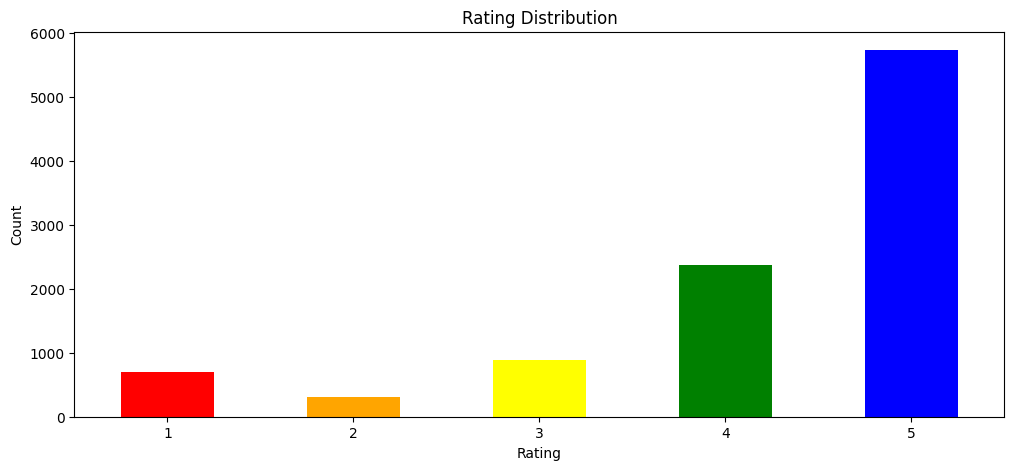

In [21]:
plt.figure(figsize=(12, 5))

rating_counts = df['rating'].value_counts().sort_index()  # 1,2,3,4,5
rating_counts.plot(kind='bar', color=['red', 'orange', 'yellow', 'green', 'blue'])

plt.title('Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

In [30]:
from wordcloud import WordCloud

positive_review = df_cleaned[df_cleaned['sentiment'] == 1]['review']
positive_text = ' '.join(positive_review)
positive_text


'nice produt. like design lot. easy carry. and. looked stylish.read awesome sound....very pretty see nd sound quality good wish take product loved product 😍😍😍read awesome sound quality. pros 7-8 hrs battery life (including 45 mins approx call time)awesome sound output. bass treble really clear without equaliser. equaliser, sound wary depends handset sound quality.weightless carry head toomic good, traffic good (3.25/5)3.5mm option really important mention. really expecting leading brands implement this.consvery tight ears. adjusters ok .. tight...read think good product per quality also design quite good . using product january ... pandamic situation became useful helpful . overall bass sound quality pretty good another thing give sigh relief provide wire help case lacking charges.read awesome bass sound quality good bettary long life purchase rs.999 really grateful product forget likeread awsome sound powerful bass battery backup also excellent loved bass huge lover music bass design 

In [32]:
wordcloud = WordCloud(width=800, height=400).generate(positive_text)
wordcloud

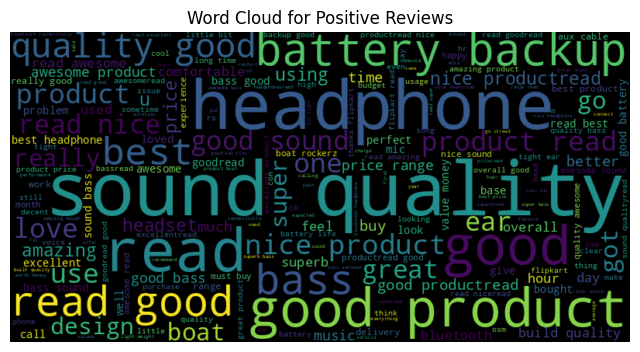

In [33]:
plt.figure(figsize=(8, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud for Positive Reviews')
plt.show()

2. Vectorize the Text Data

In [35]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(max_features=500)
vectorizer

TfidfVectorizer(max_features=500)

In [36]:
X = vectorizer.fit_transform(df_cleaned['review'])
y = df_cleaned['sentiment']

In [38]:
X.shape

(9976, 500)

In [39]:
y.shape

(9976,)

3. Train Test Split

In [41]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### 4. Build and Fit the Model

In [42]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

### 5. Make Prediction

In [47]:
test_pred = model.predict(X_test)
y_test.iloc[0] == test_pred[0]

np.True_

In [48]:
training_pred = model.predict(X_train)
y_train.iloc[0] == training_pred[0]

np.True_

### 6. Evaluate the Model

In [49]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

training_accuracy = accuracy_score(y_train, training_pred)
test_accuracy = accuracy_score(y_test, test_pred)

print(f"Training Accuracy: {training_accuracy:.3f}")
print(f"Test Accuracy: {test_accuracy:.3f}")

Training Accuracy: 0.972
Test Accuracy: 0.841


In [50]:
labels = ['Train', 'Test']
accuracy = [training_accuracy, test_accuracy]

/tmp/ipykernel_1096/3422668413.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=labels, y=accuracy, palette=['green', 'blue'])


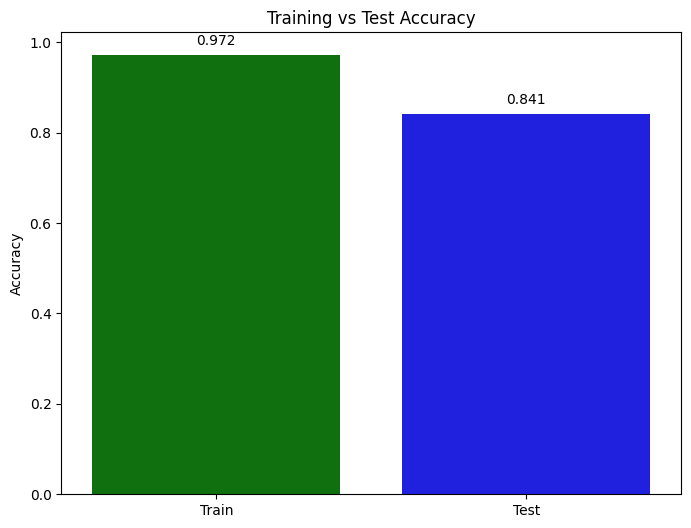

In [57]:
plt.figure(figsize=(8, 6))
ax = sns.barplot(x=labels, y=accuracy, palette=['green', 'blue'])
plt.title('Training vs Test Accuracy')
plt.ylim(0, max(1, max(accuracy) + 0.05))
plt.ylabel('Accuracy')

for p in ax.patches:
    h = p.get_height()
    ax.annotate(f'{h:.3f}',
                (p.get_x() + p.get_width() / 2, h),
                ha='center', va='bottom',
                xytext=(0, 5),
                textcoords='offset points')

plt.show()

In [59]:
cm = confusion_matrix(y_test, test_pred)
cm

array([[ 204,  152],
       [ 166, 1474]])

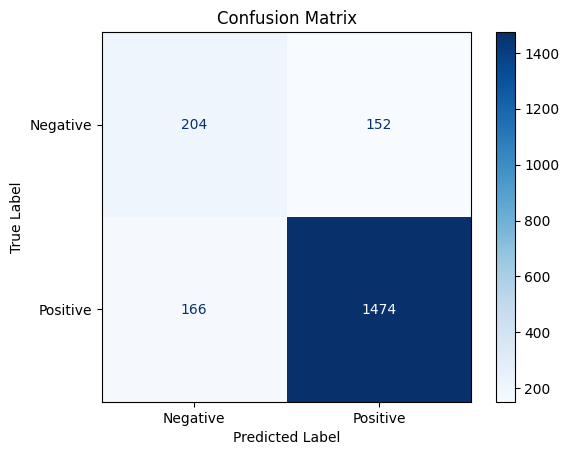

In [63]:
display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Negative', 'Positive']
 )
display.plot(cmap='Blues', colorbar=True)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()